# Example: Reading and Analyzing GRMONTY Spectral Energy Distributions

This notebook demonstrates how to read, process, and analyze spectral energy distribution (SED) outputs produced by **GPUmonty** simulations.

The main goals of this example are:
- To load GPUmonty `.spec` files using `astropy.io.ascii`
- To convert the tabulated quantities into physical units
- To reconstruct the spectral luminosity \( \nu L_\nu \) for multiple viewing angles

## What this cell does

The code cell below defines a helper function, `grmonty(file)`, which:
1. Reads a GRMONTY SED file with no header.
2. Extracts frequency bins and converts them to physical frequencies.
3. Builds arrays of luminosities for six viewing angles, converting from solar luminosities to cgs units.
5. Returns the frequency array and luminosity arrays for plotting

The notebook also defines the solid-angle weights (`domega_array`) associated with each of the six angular bins, which are typically used when computing angle-averaged spectra.

This setup provides a minimal, reproducible example for inspecting GRMONTY outputs and serves as a starting point for plotting spectra, comparing runs, or integrating over angles.

In [1]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt

#read from other models
def grmonty(file):
    """
    Reads SEDs in the format provided by grmonty.
    
    Returns:
        nu: Frequency array
        ll: Luminosity array (log10)
        tauabs: Absorption optical depth
        domega: Array of solid angles for each theta bin
    """
    LSUN = 3.827e33
    CL = 2.99792458e10
    ME = 9.1093826e-28
    HPL =  6.6260693e-27

    # 1. Parse the header for dOmega
    domega_arr = None
    with open(file, 'r') as f:
        for line in f:
            if line.startswith("# dOmega:"):
                # Split by colon to get the numbers, then split by space
                parts = line.split(':')[1].strip().split()
                domega_arr = np.array([np.float64(x) for x in parts])
                break
    
    # Check if dOmega was found; if not, you might want a default or error
    if domega_arr is None:
        print(f"Warning: No dOmega header found in {file}")

    # 2. Read the numerical data
    # format='no_header' treats lines starting with # as comments, 
    # so our new header won't break this.
    s = ascii.read(file, format='no_header')

    # Array conversions for luminosity values (log10)
    # Note: This hardcoding of 6 bins assumes N_THBINS is always 6.
    # If N_THBINS changes, this section needs to be dynamic based on domega_arr.size
    ll = np.zeros((6, len(s))) 
    ll[0] = np.array(s['col2'] * LSUN)
    ll[1] = np.array(s['col8'] * LSUN)
    ll[2] = np.array(s['col14']* LSUN)
    ll[3] = np.array(s['col20']* LSUN)
    ll[4] = np.array(s['col26']* LSUN)
    ll[5] = np.array(s['col32']* LSUN)
    
    tauabs = np.zeros((6, len(s)))
    tauabs[0] = np.array(s['col3'])     
    tauabs[1] = np.array(s['col9'])
    tauabs[2] = np.array(s['col15'])
    tauabs[3] = np.array(s['col21'])
    tauabs[4] = np.array(s['col27'])
    tauabs[5] = np.array(s['col33'])

    # Compute frequency (nu) values
    # The C code outputs log10(energy), so we convert back
    nu = np.array(10**s['col1'] * (ME * CL**2/HPL))

    return nu, ll, tauabs, domega_arr

# Example usage:
nu, nuLnu, tauabs, domega_array = grmonty('../output/spectrum_sphere.h5')
print("Read dOmega:", domega_array)

Read dOmega: [0.4281887  1.25538573 1.99703031 2.60258057 3.03076926 3.25241604]


In [6]:
import numpy as np
from scipy.special import kn  
from scipy.integrate import quad

# Constants
M_SQRT2 = np.sqrt(2)
EE = 4.80320680e-10
ME = 9.1093826e-28
CL = 2.99792458e10
JCST = M_SQRT2 * EE**3 / (27 * ME * CL**2)
CST = 1.88774862536  # 2^(11/12)
CL = 2.99792458e10  
ME = 9.1093826e-28
HPL = 6.6260693e-27
THETAE_MIN = 0.3

KMIN = 0.002
KMAX = 1e7
TMIN = 0.3
TMAX = 1e2
N_ESAMP = 2500
EPSABS = 0.
EPSREL = 1e-6
dlT = 1/(np.log(TMAX/TMIN)/N_ESAMP)
lT_min = np.log(TMIN)
F_table = np.zeros(N_ESAMP + 1)
K2_table = np.zeros(N_ESAMP + 1)

def jnu_integrand(th, K):
    """Integrand for the emissivity calculation."""
    sth = np.sin(th)
    x = K / sth
    if sth < 1.e-150 or x > 2.e8:
        return 0.
    return sth**2 * (np.sqrt(x) + CST * x**(1. / 6.))**2 * np.exp(-x**(1. / 3.))

def init_emiss_tables():
    """Initialize emissivity and Bessel function tables."""
    global F_table, K2_table
    
    dlK = np.log(KMAX / KMIN) / N_ESAMP
    dlT = np.log(TMAX / TMIN) / N_ESAMP

    for k in range(N_ESAMP + 1):
        K = np.exp(k * dlK + np.log(KMIN))
        result, err = quad(jnu_integrand, 0, np.pi / 2, args=(K), epsabs=EPSABS, epsrel=EPSREL)
        F_table[k] = np.log(4 * np.pi * result)

    for k in range(N_ESAMP + 1):
        T = np.exp(k * dlT + np.log(TMIN))
        K2_table[k] = np.log(kn(2, 1. / T))

    global inv_dlK, inv_dlT
    inv_dlK = 1. / dlK
    inv_dlT = 1. / dlT


def K2_eval(Thetae):
    """Evaluate K2 using precomputed values and interpolation."""
    if Thetae < TMIN:
        return 0.
    elif Thetae > TMAX:
        return 2. * Thetae * Thetae  # As per CUDA code
    
    if(Thetae == 100):
        return 19999.50006838941
    return linear_interp_K2(Thetae)

def linear_interp_K2(Thetae):
    """Linear interpolation for K2 evaluation."""
    lT = np.log(Thetae)
    
    di = (lT - lT_min) * inv_dlT 
    i = int(di)
    di = di - i  
    print(i, di)
    return np.exp((1. - di) * K2_table[i] + di * K2_table[i + 1])
    
KFAC = 9 * np.pi * ME * CL / EE

def linear_interp_F(K):
    """Linearly interpolate F_table for a given K value."""
    lK_min = np.log(KMIN)
    dlK = np.log(KMAX / KMIN) / N_ESAMP
    inv_dlK = 1.0 / dlK

    lK = np.log(K)
    di = (lK - lK_min) * inv_dlK
    i = int(di)
    di -= i

    if i < 0 or i >= N_ESAMP:
        return 0.

    result = np.exp((1.0 - di) * F_table[i] + di * F_table[i + 1])
    return result

def F_eval(Thetae, Bmag, nu):
    """Evaluate F using precomputed tables or approximation based on K."""
    K = KFAC * nu / (Bmag * Thetae**2)
    if K > KMAX:
        return 0.
    elif K < KMIN:
        x = K**(1 / 3)
        return x * (37.67503800178 + 2.240274341836 * x)
    else:
        return linear_interp_F(K)

def Bnu(nu, Thetae):
    """
    Calculates the Planck function B_nu at a given frequency nu and electron temperature Thetae.
    
    Parameters:
    nu (array-like): Frequency in Hz (can be an array).
    Thetae (float): Dimensionless electron temperature (Thetae = kT_e / m_e c^2).
    
    Returns:
    array: B_nu values for the given frequencies.
    """
    nu = np.array(nu, dtype=np.float64)
    
    x = HPL * nu / (ME * CL**2 * Thetae)

    result = np.zeros_like(x)
    
    mask_low = x < 1e-8
    result[mask_low] = (2. * HPL * nu[mask_low]**3 / CL**2) / (
        x[mask_low] / 24. * (24. + x[mask_low] * (12. + x[mask_low] * (4. + x[mask_low])))
    )
    
    mask_high = ~mask_low
    result[mask_high] = (2.0 * HPL * nu[mask_high]**3 / CL**2) / (np.float128(np.exp(np.float128(x[mask_high]))) - 1.0)
    
    return result

# Synchrotron emissivity function
def jnu(ne, nu, B, thetae):
    sin_value = 1
    nus = (2/9) * (EE * B/(2 * np.pi * ME * CL)) * thetae**2 * sin_value
    X = nu / nus
    factor = np.sqrt(2) * np.pi * EE**2 * ne * nus / (3 * CL * kn(2, 1/thetae))
    return factor * (X**(1/2) + 2**(11/12) * X**(1/6))**2 * np.exp(-X**(1/3))

def int_jnu(Ne, Thetae, Bmag, nu):
    """Calculate emissivity jnu using precomputed tables and F_eval, allowing nu to be an array."""
    nu = np.atleast_1d(nu)

    if Thetae < THETAE_MIN:
        return np.zeros_like(nu)

    K2 = K2_eval(Thetae)
    if K2 == 0.:
        return np.zeros_like(nu)
    
    j_fac = Ne * Bmag * Thetae**2 / K2

    F_vals = np.array([F_eval(Thetae, Bmag, n) for n in nu])
    jnu_vals = JCST * j_fac * F_vals

    return jnu_vals[0] if jnu_vals.size == 1 else jnu_vals

# Initialize tables before calculations
init_emiss_tables()

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Plotting the spectrum

/tmp/ipykernel_9236/1578126866.py:41: RuntimeWarning: invalid value encountered in divide
  relative_diff2 = (-y_analyticdata +y_simdata) / y_analyticdata


-0.0014431756489080584853


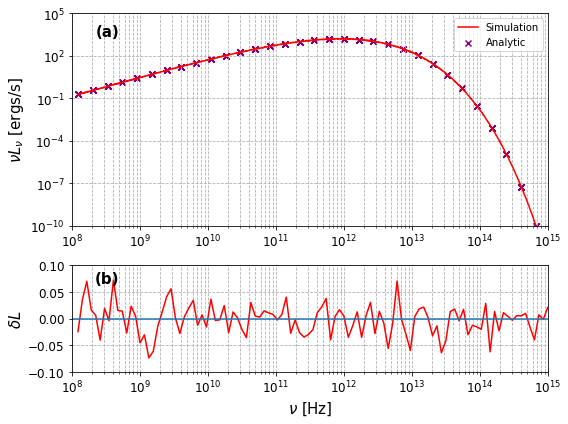

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import kn

R = 1.0000#1.00075
Rin = 0.01
jnu_values = int_jnu(1e13, 100,1,np.float128(nu))
alpha = np.float128(jnu(1e13, np.float128(nu), 1, 100))/np.float128(Bnu(np.float128(nu),100))
dv = 4/3 * np.pi * (R**3 - Rin**3)
mfp = 1 #mean free path
Luminosity_analytic = jnu_values
exp_approx = np.zeros_like(nu) 
#for i in range(len(alpha)):
#    if alpha[i] < 1e-4:
#        Luminosity_analytic[i] = int_jnu(1e13, 100, 1, nu[i])/(alpha[i]) * (mfp * alpha[i] - (mfp * alpha[i])**2/2 + (mfp * alpha[i])**3/6 + (mfp * alpha[i])**4/24)
#    else:
#        exp_approx[i] = np.exp(-mfp * alpha[i])
#        Luminosity_analytic[i] = (int_jnu(1e13, 100, 1, nu[i])/(alpha[i]) * (1 - exp_approx[i]))


# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=False, gridspec_kw={'height_ratios': [2, 1]})
xdata = nu
y_simdata = (nuLnu* domega_array[:,None]/(4* np.pi)).sum(0)
y_analyticdata = Luminosity_analytic * nu * dv

ax1.plot(nu, y_simdata, linestyle='-', label = 'Simulation', color = 'red')

ax1.scatter(nu[::50], y_analyticdata[::50], marker = 'x', label = 'Analytic', color = 'purple')
ax1.set_ylim(1e-10,1e5)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r"$\nu L_\nu$ [ergs/s]", fontsize = 15)
ax1.grid(True, which="both", ls="--")
ax1.set_xlim(1e8, 1e15)
ax1.tick_params(axis='both', which='major', labelsize=12)  # Adjust major tick size
ax1.text(0.1, 0.95, '(a)', transform=ax1.transAxes, ha='right', va='top', fontweight = 'bold', fontsize = 15)
ax1.legend()


relative_diff2 = (-y_analyticdata +y_simdata) / y_analyticdata

ax2.plot(xdata[::15], relative_diff2[::15], color='r', label = 'analy')
ax2.axhline(np.mean(relative_diff2[:1591]))
print(np.mean(relative_diff2[:1591]))
ax2.set_xscale('log')
ax2.text(0.1, 0.95, '(b)', transform=ax2.transAxes, ha='right', va='top',fontweight = 'bold',fontsize = 15)

ax2.set_ylabel(r'$\delta L$', fontsize = 15)
ax2.grid(True, which="both", ls="--")
ax2.set_ylim(-0.1, 0.1)
ax2.set_xlim(1e8,1e15)
ax2.tick_params(axis='both', which='major', labelsize=12) 
ax2.set_xlabel(r"$\nu$ [Hz]", fontsize = 15)


plt.tight_layout()
plt.show()